# Proyecto Final - Ciencia de Datos II
## Predicción de cancelación de clientes - NewLinkWireless

### 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [ ]:
df = pd.read_csv("/content/dataset_cancelacion_newlinkwireless.csv")

print("Dataset cargado correctamente.")
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

df.head()

Dataset cargado correctamente.
Cantidad de filas: 1000
Cantidad de columnas: 21


,id_servicio,tipo_cliente,tipo_servicio,plan,velocidad_bajada_mbps,velocidad_subida_mbps,precio_contratado,antiguedad_meses,cantidad_equipos,cantidad_tickets,...,tickets_criticos,promedio_dias_resolucion,cantidad_facturas,facturas_vencidas,monto_facturado,monto_pagado,saldo_pendiente,dias_atraso_promedio,cantidad_interacciones,cancelo_servicio
0,1,Persona natural,Fibra óptica,Fibra 500 Mbps,500,250,1480,22,2,3,...,0,2.61,18,3,30636.0,24721.71,5914.29,6.17,5,1
1,2,Persona natural,Cable,Cable 100 Mbps,100,20,736,24,2,8,...,6,9.17,18,8,15235.2,12820.63,2414.57,16.83,9,0
2,3,Persona natural,Fibra óptica,Fibra 200 Mbps,200,100,1032,39,2,4,...,2,7.23,18,5,21362.4,19565.62,1796.78,9.44,5,0
3,4,Persona natural,Cable,Cable 50 Mbps,50,10,549,34,2,2,...,0,1.03,18,3,11364.3,11072.23,292.07,0.35,3,0
4,5,Persona natural,Cable,Cable 100 Mbps,100,20,720,34,2,2,...,0,1.27,18,6,14904.0,14541.95,362.05,1.39,3,0


### 2. Exploración inicial del dataset

Antes de realizar la limpieza, se analiza la estructura y calidad del dataset para identificar valores nulos, registros duplicados, tipos de datos e inconsistencias.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_servicio               1000 non-null   int64  
 1   tipo_cliente              1000 non-null   object 
 2   tipo_servicio             1000 non-null   object 
 3   plan                      1000 non-null   object 
 4   velocidad_bajada_mbps     1000 non-null   int64  
 5   velocidad_subida_mbps     1000 non-null   int64  
 6   precio_contratado         1000 non-null   int64  
 7   antiguedad_meses          1000 non-null   int64  
 8   cantidad_equipos          1000 non-null   int64  
 9   cantidad_tickets          1000 non-null   int64  
 10  tickets_abiertos          1000 non-null   int64  
 11  tickets_criticos          1000 non-null   int64  
 12  promedio_dias_resolucion  1000 non-null   float64
 13  cantidad_facturas         1000 non-null   int64  
 14  facturas_

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nTotal de valores nulos:", df.isnull().sum().sum())

Valores nulos por columna:
id_servicio                 0
tipo_cliente                0
tipo_servicio               0
plan                        0
velocidad_bajada_mbps       0
velocidad_subida_mbps       0
precio_contratado           0
antiguedad_meses            0
cantidad_equipos            0
cantidad_tickets            0
tickets_abiertos            0
tickets_criticos            0
promedio_dias_resolucion    0
cantidad_facturas           0
facturas_vencidas           0
monto_facturado             0
monto_pagado                0
saldo_pendiente             0
dias_atraso_promedio        0
cantidad_interacciones      0
cancelo_servicio            0
dtype: int64

Total de valores nulos: 0


In [ ]:
duplicados = df.duplicated().sum()

print("Registros duplicados:", duplicados)

Registros duplicados: 0


In [ ]:
df.describe()

,id_servicio,velocidad_bajada_mbps,velocidad_subida_mbps,precio_contratado,antiguedad_meses,cantidad_equipos,cantidad_tickets,tickets_abiertos,tickets_criticos,promedio_dias_resolucion,cantidad_facturas,facturas_vencidas,monto_facturado,monto_pagado,saldo_pendiente,dias_atraso_promedio,cantidad_interacciones,cancelo_servicio
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,157.550000,78.47000,1087.308000,29.599000,2.059000,2.682000,0.565000,0.601000,4.835110,16.503000,2.735000,20561.542300,18466.840430,2094.701870,7.52527,3.687000,0.201000
std,288.819436,159.530397,92.89989,1077.588484,14.381552,0.235743,2.411367,0.853524,1.118503,4.623322,3.277306,2.207181,21041.867502,19342.305423,3451.576093,7.19879,2.328616,0.400949
min,1.000000,20.000000,10.00000,450.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,2267.800000,1619.350000,3.420000,0.00000,1.000000,0.000000
25%,250.750000,50.000000,10.00000,614.000000,19.000000,2.000000,1.000000,0.000000,0.000000,1.480000,18.000000,1.000000,11483.325000,10115.382500,413.762500,1.76750,2.000000,0.000000
50%,500.500000,100.000000,20.00000,762.500000,28.000000,2.000000,2.000000,0.000000,0.000000,2.995000,18.000000,2.000000,14599.250000,13095.920000,1107.980000,4.58500,3.000000,0.000000
75%,750.250000,200.000000,100.00000,1016.250000,40.000000,2.000000,4.000000,1.000000,1.000000,7.300000,18.000000,4.000000,20639.625000,19421.757500,2610.617500,11.77000,5.000000,0.000000
max,1000.000000,500.000000,300.00000,6045.000000,60.000000,3.000000,10.000000,3.000000,6.000000,19.750000,18.000000,13.000000,125131.500000,123893.370000,44280.850000,29.86000,10.000000,1.000000


In [ ]:
columnas_categoricas = df.select_dtypes(include="object").columns

for columna in columnas_categoricas:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts())


--- tipo_cliente ---
tipo_cliente
Persona natural    854
Empresa            146
Name: count, dtype: int64

--- tipo_servicio ---
tipo_servicio
Fibra óptica       397
Cable              283
Inalámbrico        261
Enlace dedicado     59
Name: count, dtype: int64

--- plan ---
plan
Fibra 500 Mbps         152
Cable 50 Mbps          151
Fibra 200 Mbps         142
Inalámbrico 20 Mbps    135
Cable 100 Mbps         132
Inalámbrico 50 Mbps    126
Fibra 100 Mbps         103
Dedicado 300 Mbps       36
Dedicado 100 Mbps       23
Name: count, dtype: int64


In [ ]:
print("Tickets abiertos mayores al total:")
print((df["tickets_abiertos"] > df["cantidad_tickets"]).sum())

print("\nTickets críticos mayores al total:")
print((df["tickets_criticos"] > df["cantidad_tickets"]).sum())

print("\nSaldos pendientes negativos:")
print((df["saldo_pendiente"] < 0).sum())

print("\nPrecios negativos o iguales a cero:")
print((df["precio_contratado"] <= 0).sum())

print("\nAntigüedad negativa:")
print((df["antiguedad_meses"] < 0).sum())

print("\nValores distintos de 0 y 1 en cancelo_servicio:")
print(df.loc[~df["cancelo_servicio"].isin([0, 1]), "cancelo_servicio"].count())

Tickets abiertos mayores al total:
1

Tickets críticos mayores al total:
2

Saldos pendientes negativos:
0

Precios negativos o iguales a cero:
0

Antigüedad negativa:
0

Valores distintos de 0 y 1 en cancelo_servicio:
0


### 3. Limpieza de datos

A partir de la exploración inicial se verificó la calidad del dataset mediante la revisión de valores nulos, registros duplicados, tipos de datos, categorías e inconsistencias lógicas.

El dataset presentó una buena calidad general. Sin embargo, se identificaron inconsistencias en las variables relacionadas con tickets, específicamente registros donde la cantidad de tickets abiertos o críticos era superior a la cantidad total de tickets. Estas inconsistencias serán corregidas antes de continuar con el análisis.

In [ ]:
inconsistencias_tickets = df[
    (df["tickets_abiertos"] > df["cantidad_tickets"]) |
    (df["tickets_criticos"] > df["cantidad_tickets"])
]

inconsistencias_tickets[
    ["id_servicio", "cantidad_tickets", "tickets_abiertos", "tickets_criticos"]
]

,id_servicio,cantidad_tickets,tickets_abiertos,tickets_criticos
106,107,0,0,1
335,336,0,1,0
717,718,5,3,6


#### Corrección de inconsistencias en tickets

Se identificaron tres registros con inconsistencias lógicas en las variables relacionadas con tickets. Debido a que la cantidad de tickets abiertos y críticos no puede superar la cantidad total de tickets registrados, se ajustaron estos valores tomando como límite máximo la cantidad total de tickets de cada servicio.

In [ ]:
df["tickets_abiertos"] = df[
    ["tickets_abiertos", "cantidad_tickets"]
].min(axis=1)

df["tickets_criticos"] = df[
    ["tickets_criticos", "cantidad_tickets"]
].min(axis=1)

print("Inconsistencias corregidas.")

Inconsistencias corregidas.


In [ ]:
print(
    "Tickets abiertos mayores al total:",
    (df["tickets_abiertos"] > df["cantidad_tickets"]).sum()
)

print(
    "Tickets críticos mayores al total:",
    (df["tickets_criticos"] > df["cantidad_tickets"]).sum()
)

Tickets abiertos mayores al total: 0
Tickets críticos mayores al total: 0


#### Verificación final de consistencia

Después de corregir las inconsistencias detectadas en los tickets, se realizó una verificación adicional de las variables financieras y operativas para confirmar la coherencia del dataset.

In [ ]:
# Verificar coherencia de las variables financieras
diferencia_saldo = (
    df["monto_facturado"] -
    df["monto_pagado"] -
    df["saldo_pendiente"]
).abs()

print(
    "Saldos pendientes inconsistentes:",
    (diferencia_saldo > 0.01).sum()
)

print(
    "Monto pagado mayor al facturado:",
    (df["monto_pagado"] > df["monto_facturado"]).sum()
)

print(
    "Facturas vencidas mayores al total:",
    (df["facturas_vencidas"] > df["cantidad_facturas"]).sum()
)

print(
    "Valores negativos en cantidad de tickets:",
    (df["cantidad_tickets"] < 0).sum()
)

print(
    "Valores negativos en días de atraso:",
    (df["dias_atraso_promedio"] < 0).sum()
)

Saldos pendientes inconsistentes: 0
Monto pagado mayor al facturado: 0
Facturas vencidas mayores al total: 0
Valores negativos en cantidad de tickets: 0
Valores negativos en días de atraso: 0


#### Resultado de la limpieza

Después de realizar las verificaciones de calidad y consistencia, se corrigieron tres registros que presentaban inconsistencias en las variables `tickets_abiertos` y `tickets_criticos`.

También se comprobó que no existen saldos pendientes inconsistentes, montos pagados superiores a los facturados, facturas vencidas superiores al total de facturas, cantidades negativas de tickets ni valores negativos en los días promedio de atraso.

Después de estas correcciones y verificaciones, el dataset queda preparado para continuar con el Análisis Exploratorio de Datos (EDA).

In [ ]:
df.to_csv(
    "/content/dataset_cancelacion_newlinkwireless_limpio.csv",
    index=False
)

print("Dataset limpio guardado correctamente.")
print("Dimensiones finales:", df.shape)

Dataset limpio guardado correctamente.
Dimensiones finales: (1000, 21)


### 4. Análisis Exploratorio de Datos (EDA)

En esta etapa se analizará el comportamiento de las principales variables del dataset y su relación con la cancelación del servicio.

El objetivo es identificar patrones que puedan ayudar a comprender qué características están asociadas con una mayor probabilidad de cancelación.

#### Distribución de cancelación del servicio

Se analizará la cantidad de servicios cancelados y no cancelados para conocer cómo se distribuye la variable objetivo dentro del dataset.

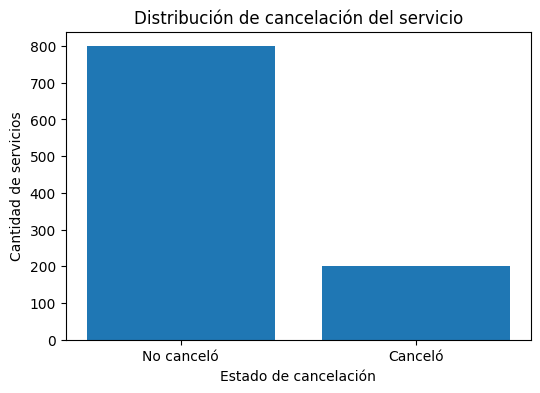

In [ ]:
import matplotlib.pyplot as plt

conteo_cancelacion = df["cancelo_servicio"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["No canceló", "Canceló"],
    conteo_cancelacion.values
)

plt.title("Distribución de cancelación del servicio")
plt.xlabel("Estado de cancelación")
plt.ylabel("Cantidad de servicios")

plt.show()

#### Interpretación

De los 1,000 servicios analizados, aproximadamente el **20.1% corresponde a servicios cancelados**, mientras que el **79.9% no presenta cancelación**.

Esto evidencia un desbalance entre las clases de la variable objetivo. Por esta razón, al evaluar los modelos de clasificación no se utilizará únicamente el Accuracy, sino también métricas como Precision, Recall y F1-Score, especialmente para evaluar la capacidad del modelo de identificar correctamente las cancelaciones.

#### Cancelación por tipo de servicio

Se analizará el porcentaje de cancelación según el tipo de servicio para identificar si existen diferencias entre fibra óptica, cable, inalámbrico y enlace dedicado.

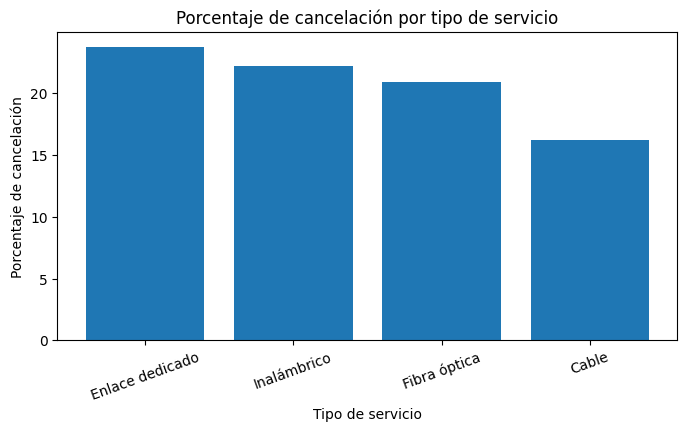

In [ ]:
cancelacion_servicio = (
    df.groupby("tipo_servicio")["cancelo_servicio"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8, 4))

plt.bar(
    cancelacion_servicio.index,
    cancelacion_servicio.values
)

plt.title("Porcentaje de cancelación por tipo de servicio")
plt.xlabel("Tipo de servicio")
plt.ylabel("Porcentaje de cancelación")

plt.xticks(rotation=20)

plt.show()

In [ ]:
print(cancelacion_servicio.round(2))

tipo_servicio
Enlace dedicado    23.73
Inalámbrico        22.22
Fibra óptica       20.91
Cable              16.25
Name: cancelo_servicio, dtype: float64


#### Cantidad de tickets según cancelación

Se analizará la cantidad promedio de tickets de soporte registrados para los servicios cancelados y no cancelados.

Este análisis permite observar si los clientes que presentan una mayor cantidad de solicitudes de soporte también muestran una mayor tendencia a cancelar el servicio.

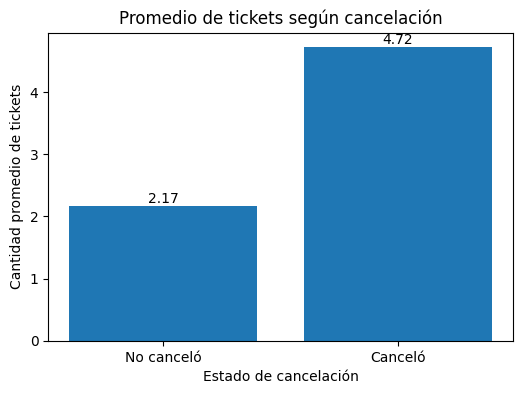

cancelo_servicio
0    2.168961
1    4.721393
Name: cantidad_tickets, dtype: float64


In [ ]:
promedio_tickets = (
    df.groupby("cancelo_servicio")["cantidad_tickets"]
    .mean()
)

plt.figure(figsize=(6, 4))

barras = plt.bar(
    ["No canceló", "Canceló"],
    promedio_tickets.values
)

plt.title("Promedio de tickets según cancelación")
plt.xlabel("Estado de cancelación")
plt.ylabel("Cantidad promedio de tickets")

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

print(promedio_tickets)

#### Interpretación

Los servicios cancelados registraron un promedio de aproximadamente **4.72 tickets de soporte**, mientras que los servicios que no fueron cancelados presentaron un promedio de **2.17 tickets**.

Esto muestra que, dentro del dataset analizado, los servicios cancelados acumularon más del doble de tickets de soporte en promedio. El resultado sugiere una asociación entre una mayor cantidad de solicitudes de soporte y la cancelación del servicio.

Por lo tanto, `cantidad_tickets` puede ser una variable relevante para el modelo predictivo y para identificar clientes que podrían requerir mayor atención.

#### Facturas vencidas según cancelación

Se analizará la cantidad promedio de facturas vencidas para los servicios cancelados y no cancelados.

Este análisis permite observar si los clientes con más facturas vencidas presentan una mayor tendencia a cancelar el servicio.

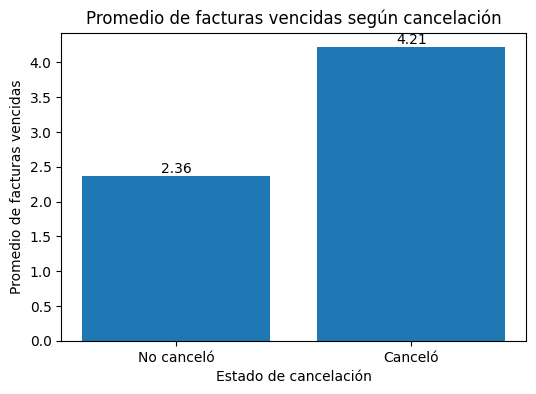

cancelo_servicio
0    2.362954
1    4.213930
Name: facturas_vencidas, dtype: float64


In [ ]:
promedio_facturas_vencidas = (
    df.groupby("cancelo_servicio")["facturas_vencidas"]
    .mean()
)

plt.figure(figsize=(6, 4))

barras = plt.bar(
    ["No canceló", "Canceló"],
    promedio_facturas_vencidas.values
)

plt.title("Promedio de facturas vencidas según cancelación")
plt.xlabel("Estado de cancelación")
plt.ylabel("Promedio de facturas vencidas")

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

print(promedio_facturas_vencidas)

#### Interpretación

Los servicios cancelados presentaron un promedio de aproximadamente **4.21 facturas vencidas**, mientras que los servicios no cancelados registraron un promedio de **2.36**.

Dentro del dataset analizado, se observa una asociación entre una mayor cantidad de facturas vencidas y la cancelación del servicio. Esto indica que el comportamiento de pago puede aportar información relevante para identificar servicios con mayor riesgo de cancelación.

Por esta razón, `facturas_vencidas` se considera una variable de interés para el posterior modelo de clasificación.

#### Días promedio de atraso según cancelación

Se analizará el promedio de días de atraso de los servicios cancelados y no cancelados.

Este análisis permite observar si los clientes que presentan mayores retrasos en sus pagos también muestran una mayor tendencia a cancelar el servicio.

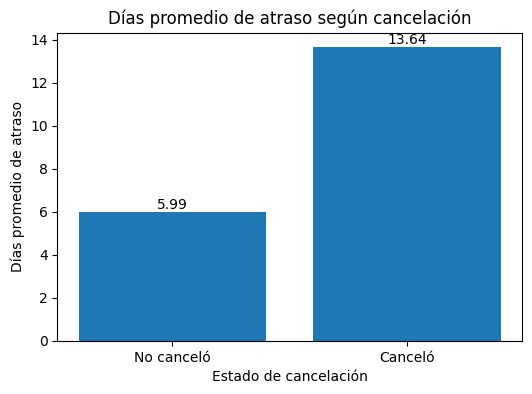

cancelo_servicio
0     5.986834
1    13.640746
Name: dias_atraso_promedio, dtype: float64


In [ ]:
promedio_dias_atraso = (
    df.groupby("cancelo_servicio")["dias_atraso_promedio"]
    .mean()
)

plt.figure(figsize=(6, 4))

barras = plt.bar(
    ["No canceló", "Canceló"],
    promedio_dias_atraso.values
)

plt.title("Días promedio de atraso según cancelación")
plt.xlabel("Estado de cancelación")
plt.ylabel("Días promedio de atraso")

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

print(promedio_dias_atraso)

#### Interpretación

Los servicios que fueron cancelados presentaron un atraso promedio de aproximadamente **13.64 días**, mientras que los servicios no cancelados registraron un promedio de **5.99 días**.

La diferencia observada muestra que, dentro del dataset analizado, los servicios cancelados presentan retrasos de pago considerablemente mayores. Esto sugiere que `dias_atraso_promedio` puede aportar información relevante para identificar patrones asociados con la cancelación.

Este comportamiento también complementa el resultado observado en las facturas vencidas, mostrando que las variables relacionadas con el cumplimiento de pagos pueden ser importantes para el análisis predictivo.

#### Antigüedad del cliente y cancelación

La antigüedad del servicio puede ayudar a determinar si existe una diferencia en el comportamiento de cancelación entre clientes recientes y clientes con mayor permanencia en la empresa.

In [ ]:
# Promedio de antigüedad según cancelación
antiguedad_cancelacion = df.groupby(
    "cancelo_servicio"
)["antiguedad_meses"].agg(["mean", "median", "min", "max"])

antiguedad_cancelacion

,mean,median,min,max
cancelo_servicio,,,,
0,32.052566,31.0,4,60
1,19.845771,18.0,4,52


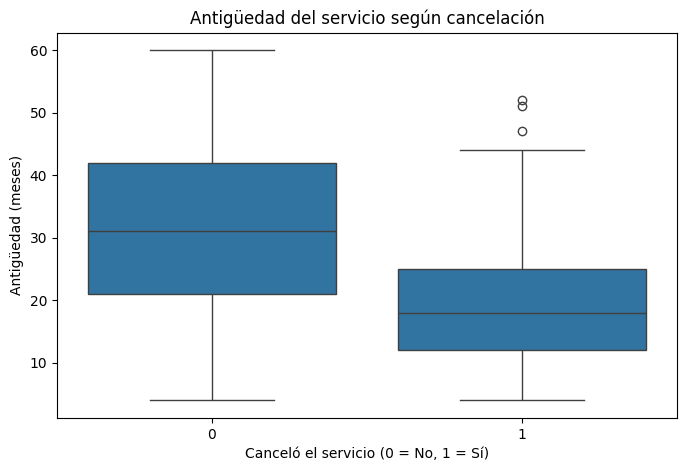

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="cancelo_servicio",
    y="antiguedad_meses"
)

plt.title("Antigüedad del servicio según cancelación")
plt.xlabel("Canceló el servicio (0 = No, 1 = Sí)")
plt.ylabel("Antigüedad (meses)")

plt.show()

#### Interpretación

Los servicios que no fueron cancelados presentan una antigüedad promedio de aproximadamente **32.05 meses**, mientras que los servicios cancelados registran un promedio de **19.85 meses**.

La mediana también refleja esta diferencia: **31 meses** para los servicios no cancelados frente a **18 meses** para los cancelados.

Dentro del dataset analizado, estos resultados muestran una asociación entre una menor antigüedad y la cancelación del servicio. Por lo tanto, `antiguedad_meses` puede ser una variable relevante para el modelo predictivo. Este resultado representa una asociación y no implica necesariamente una relación causal.

### 5. Preparación de los datos para Machine Learning

Para desarrollar los modelos de clasificación, se utiliza `cancelo_servicio` como variable objetivo, donde **0 representa un servicio no cancelado y 1 un servicio cancelado**.

La variable `id_servicio` se excluye del entrenamiento debido a que funciona únicamente como identificador y no representa una característica útil para predecir la cancelación.

Las variables categóricas, como el tipo de cliente, tipo de servicio y plan contratado, se transforman mediante **One-Hot Encoding**, permitiendo que puedan ser utilizadas por los algoritmos de Machine Learning.

Posteriormente, el dataset se divide en un conjunto de **entrenamiento (80%)** y un conjunto de **prueba (20%)**. La división se realiza de forma estratificada para conservar aproximadamente la misma proporción de servicios cancelados y no cancelados en ambos conjuntos.

In [ ]:
X = df.drop(columns=["cancelo_servicio", "id_servicio"])
y = df["cancelo_servicio"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nDistribución de la variable objetivo:")
print(y.value_counts())

print("\nPorcentaje:")
print(y.value_counts(normalize=True) * 100)

Dimensiones de X: (1000, 19)
Dimensiones de y: (1000,)

Distribución de la variable objetivo:
cancelo_servicio
0    799
1    201
Name: count, dtype: int64

Porcentaje:
cancelo_servicio
0    79.9
1    20.1
Name: proportion, dtype: float64


#### Separación de variables categóricas y numéricas

El dataset contiene variables numéricas y categóricas. Para poder utilizar correctamente los modelos de clasificación, se identificarán ambos tipos de variables.

Las variables categóricas deberán transformarse a valores numéricos antes del entrenamiento, mientras que las variables numéricas podrán conservarse con sus valores originales.

In [ ]:
columnas_categoricas = [
    "tipo_cliente",
    "tipo_servicio",
    "plan"
]

columnas_numericas = [
    columna for columna in X.columns
    if columna not in columnas_categoricas
]

print("Variables categóricas:")
print(columnas_categoricas)

print("\nVariables numéricas:")
print(columnas_numericas)

Variables categóricas:
['tipo_cliente', 'tipo_servicio', 'plan']

Variables numéricas:
['velocidad_bajada_mbps', 'velocidad_subida_mbps', 'precio_contratado', 'antiguedad_meses', 'cantidad_equipos', 'cantidad_tickets', 'tickets_abiertos', 'tickets_criticos', 'promedio_dias_resolucion', 'cantidad_facturas', 'facturas_vencidas', 'monto_facturado', 'monto_pagado', 'saldo_pendiente', 'dias_atraso_promedio', 'cantidad_interacciones']


#### Preprocesamiento de variables categóricas

Las variables categóricas deben transformarse a una representación numérica para que puedan ser utilizadas por los modelos de clasificación.

Para este proceso se utilizará One-Hot Encoding, una técnica que crea columnas binarias a partir de cada categoría, evitando asignar un orden artificial entre los valores.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            columnas_categoricas
        ),
        (
            "numericas",
            StandardScaler(),
            columnas_numericas
        )
    ]
)

print("Preprocesador preparado correctamente.")

Preprocesador preparado correctamente.


#### División del dataset en entrenamiento y prueba

El dataset se dividirá en dos grupos: 80% de los registros se utilizarán para entrenar los modelos y el 20% restante se reservará para evaluar su desempeño.

Además, se utilizará una división estratificada para mantener una proporción similar de clientes activos y cancelados en ambos conjuntos.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución en prueba:")
print(y_test.value_counts())

Datos de entrenamiento: (800, 19)
Datos de prueba: (200, 19)

Distribución en entrenamiento:
cancelo_servicio
0    639
1    161
Name: count, dtype: int64

Distribución en prueba:
cancelo_servicio
0    160
1     40
Name: count, dtype: int64


### 6. Entrenamiento de modelos de clasificación

#### Regresión Logística

La Regresión Logística se utilizará como primer modelo de clasificación para estimar la probabilidad de que un cliente cancele el servicio.

Este modelo permite trabajar con una variable objetivo binaria, en este caso `cancelo_servicio`, donde 0 representa que el cliente no canceló y 1 que sí canceló.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(max_iter=1000))
])

modelo_logistico.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


#### Evaluación de la Regresión Logística

Una vez entrenado el modelo, se utilizará el conjunto de prueba para generar predicciones y compararlas con los valores reales.

Para evaluar su desempeño se utilizarán las métricas Accuracy, Precision, Recall y F1-Score. Estas métricas permiten analizar el comportamiento del modelo más allá del porcentaje general de predicciones correctas.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_logistico = modelo_logistico.predict(X_test)

accuracy_logistico = accuracy_score(y_test, y_pred_logistico)
precision_logistico = precision_score(y_test, y_pred_logistico)
recall_logistico = recall_score(y_test, y_pred_logistico)
f1_logistico = f1_score(y_test, y_pred_logistico)

print("Resultados - Regresión Logística")
print("--------------------------------")
print(f"Accuracy:  {accuracy_logistico:.4f}")
print(f"Precision: {precision_logistico:.4f}")
print(f"Recall:    {recall_logistico:.4f}")
print(f"F1-Score:  {f1_logistico:.4f}")

Resultados - Regresión Logística
--------------------------------
Accuracy:  0.8300
Precision: 0.6071
Recall:    0.4250
F1-Score:  0.5000


#### Árbol de Decisión

Como segundo modelo se utilizará un Árbol de Decisión. Este algoritmo clasifica los registros mediante una serie de decisiones basadas en las características de los clientes.

Se utilizará una profundidad máxima limitada para evitar que el modelo se vuelva demasiado complejo y se ajuste excesivamente a los datos de entrenamiento.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

modelo_arbol.fit(X_train, y_train)

print("Modelo de Árbol de Decisión entrenado correctamente.")

Modelo de Árbol de Decisión entrenado correctamente.


#### Evaluación del Árbol de Decisión

Después de entrenar el Árbol de Decisión, se utilizará el conjunto de prueba para generar predicciones y compararlas con los valores reales.

Se emplearán las mismas métricas utilizadas en la Regresión Logística para poder realizar una comparación directa entre ambos modelos.

In [ ]:
y_pred_arbol = modelo_arbol.predict(X_test)

accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
precision_arbol = precision_score(y_test, y_pred_arbol)
recall_arbol = recall_score(y_test, y_pred_arbol)
f1_arbol = f1_score(y_test, y_pred_arbol)

print("Resultados - Árbol de Decisión")
print("--------------------------------")
print(f"Accuracy:  {accuracy_arbol:.4f}")
print(f"Precision: {precision_arbol:.4f}")
print(f"Recall:    {recall_arbol:.4f}")
print(f"F1-Score:  {f1_arbol:.4f}")

Resultados - Árbol de Decisión
--------------------------------
Accuracy:  0.8250
Precision: 0.5610
Recall:    0.5750
F1-Score:  0.5679


#### Matriz de confusión del Árbol de Decisión

La matriz de confusión permite analizar con mayor detalle los aciertos y errores del modelo seleccionado, diferenciando los servicios correctamente clasificados de los falsos positivos y falsos negativos.

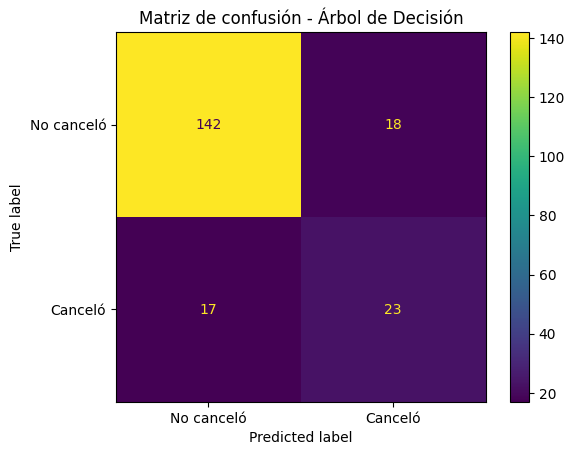

[[142  18]
 [ 17  23]]


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Crear matriz de confusión
matriz = confusion_matrix(y_test, y_pred_arbol)

# Mostrar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["No canceló", "Canceló"]
)

disp.plot()
plt.title("Matriz de confusión - Árbol de Decisión")
plt.show()

print(matriz)

#### Interpretación de la matriz de confusión

El Árbol de Decisión fue evaluado utilizando 200 registros del conjunto de prueba. El modelo clasificó correctamente **142 servicios que no fueron cancelados** y logró identificar correctamente **23 de los 40 servicios que sí fueron cancelados**.

Por otra parte, se registraron **18 falsos positivos**, correspondientes a servicios que fueron clasificados como cancelaciones aunque realmente no cancelaron, y **17 falsos negativos**, que representan cancelaciones reales que el modelo no logró identificar.

Esto explica el Recall de **57.5%**, ya que el modelo detectó 23 de las 40 cancelaciones reales presentes en el conjunto de prueba. Los resultados muestran que el modelo puede utilizarse como herramienta de apoyo para priorizar clientes que requieren seguimiento, pero sus predicciones no deben interpretarse como una certeza de cancelación.

#### Random Forest

Como tercer modelo se utilizará Random Forest. Este algoritmo combina múltiples árboles de decisión y utiliza el resultado conjunto de estos árboles para realizar la clasificación.

El objetivo de utilizar varios árboles es reducir la dependencia de un solo modelo y obtener predicciones más estables.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

modelo_rf.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


#### Evaluación de Random Forest

Después de entrenar el modelo Random Forest, se utilizará el conjunto de prueba para generar predicciones.

Los resultados se evaluarán con Accuracy, Precision, Recall y F1-Score, utilizando las mismas métricas aplicadas a los modelos anteriores.

In [ ]:
y_pred_rf = modelo_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Resultados - Random Forest")
print("--------------------------")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

Resultados - Random Forest
--------------------------
Accuracy:  0.8350
Precision: 0.6129
Recall:    0.4750
F1-Score:  0.5352


#### Comparación de los modelos

Después de evaluar los tres modelos, se compararán sus métricas para analizar sus diferencias y determinar cuál presenta un comportamiento más adecuado para el objetivo del proyecto.

In [ ]:
import pandas as pd

comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Árbol de Decisión",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistico,
        accuracy_arbol,
        accuracy_rf
    ],
    "Precision": [
        precision_logistico,
        precision_arbol,
        precision_rf
    ],
    "Recall": [
        recall_logistico,
        recall_arbol,
        recall_rf
    ],
    "F1-Score": [
        f1_logistico,
        f1_arbol,
        f1_rf
    ]
})

comparacion_modelos

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.830,0.607143,0.425,0.500000
1,Árbol de Decisión,0.825,0.560976,0.575,0.567901
2,Random Forest,0.835,0.612903,0.475,0.535211


#### Selección del modelo final

Después de comparar los tres modelos, se seleccionó el Árbol de Decisión como modelo principal para el proyecto.

Aunque Random Forest obtuvo el mayor Accuracy y Precision, el Árbol de Decisión presentó el mayor Recall y F1-Score. Esto significa que logró identificar una mayor proporción de los clientes que realmente cancelaron el servicio y mantuvo un mejor equilibrio entre la detección de cancelaciones y las falsas alertas.

Debido a que el objetivo de NewLinkWireless es identificar clientes con riesgo de cancelación para poder tomar acciones preventivas, se consideró más importante priorizar la capacidad de detección de cancelaciones reales.

### 7. Generación de resultados para Power BI

Después de seleccionar el Árbol de Decisión como modelo final, se utilizará el dataset completo para generar una estimación del riesgo de cancelación de cada servicio.

Los resultados incluirán la probabilidad estimada de cancelación, la predicción del modelo y una clasificación de riesgo en tres niveles: Bajo, Medio y Alto.

In [ ]:
from sklearn.base import clone

modelo_final_completo = clone(modelo_arbol)

modelo_final_completo.fit(X, y)

print("Modelo final entrenado con el dataset completo.")

Modelo final entrenado con el dataset completo.


In [ ]:
df_resultados = df.copy()

df_resultados["probabilidad_cancelacion"] = (
    modelo_final_completo.predict_proba(X)[:, 1]
)

df_resultados["prediccion_cancelacion"] = (
    modelo_final_completo.predict(X)
)

df_resultados.head()

,id_servicio,tipo_cliente,tipo_servicio,plan,velocidad_bajada_mbps,velocidad_subida_mbps,precio_contratado,antiguedad_meses,cantidad_equipos,cantidad_tickets,...,cantidad_facturas,facturas_vencidas,monto_facturado,monto_pagado,saldo_pendiente,dias_atraso_promedio,cantidad_interacciones,cancelo_servicio,probabilidad_cancelacion,prediccion_cancelacion
0,1,Persona natural,Fibra óptica,Fibra 500 Mbps,500,250,1480,22,2,3,...,18,3,30636.0,24721.71,5914.29,6.17,5,1,0.407407,0
1,2,Persona natural,Cable,Cable 100 Mbps,100,20,736,24,2,8,...,18,8,15235.2,12820.63,2414.57,16.83,9,0,0.300000,0
2,3,Persona natural,Fibra óptica,Fibra 200 Mbps,200,100,1032,39,2,4,...,18,5,21362.4,19565.62,1796.78,9.44,5,0,0.113821,0
3,4,Persona natural,Cable,Cable 50 Mbps,50,10,549,34,2,2,...,18,3,11364.3,11072.23,292.07,0.35,3,0,0.000000,0
4,5,Persona natural,Cable,Cable 100 Mbps,100,20,720,34,2,2,...,18,6,14904.0,14541.95,362.05,1.39,3,0,0.000000,0


In [ ]:
def clasificar_riesgo(probabilidad):
    if probabilidad < 0.30:
        return "Bajo"
    elif probabilidad < 0.60:
        return "Medio"
    else:
        return "Alto"

df_resultados["nivel_riesgo"] = (
    df_resultados["probabilidad_cancelacion"]
    .apply(clasificar_riesgo)
)

df_resultados[
    [
        "id_servicio",
        "probabilidad_cancelacion",
        "prediccion_cancelacion",
        "nivel_riesgo"
    ]
].head(10)

,id_servicio,probabilidad_cancelacion,prediccion_cancelacion,nivel_riesgo
0,1,0.407407,0,Medio
1,2,0.300000,0,Medio
2,3,0.113821,0,Bajo
3,4,0.000000,0,Bajo
4,5,0.000000,0,Bajo
5,6,0.000000,0,Bajo
6,7,0.000000,0,Bajo
7,8,0.000000,0,Bajo
8,9,0.303704,0,Medio
9,10,0.000000,0,Bajo


In [ ]:
print("Distribución por nivel de riesgo:")
print(df_resultados["nivel_riesgo"].value_counts())

print("\nPredicción de cancelación:")
print(df_resultados["prediccion_cancelacion"].value_counts())

Distribución por nivel de riesgo:
nivel_riesgo
Bajo     655
Medio    238
Alto     107
Name: count, dtype: int64

Predicción de cancelación:
prediccion_cancelacion
0    893
1    107
Name: count, dtype: int64


In [ ]:
df_resultados.to_csv(
    "/content/dataset_resultados_modelo_newlinkwireless.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV generado correctamente.")
print("Dimensiones:", df_resultados.shape)

CSV generado correctamente.
Dimensiones: (1000, 24)
